In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML

HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');

body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")


<div class="usecase-header-bar">
<div class="usecase-title">2025 Drinking Fountain Analysis</div>
</div>

<div class="usecase-details"><b>Author:</b> Katrine Chen</div>
<div class="usecase-details"><b>Created:</b> Trimester 2, 2024</div>
<div class="usecase-details"><b>Updated:</b> Trimester 2, 2026 (Maanak Gadia)</div>
<div class="usecase-details"><b>Time to Complete:</b> 90 mins</div>
<div class="usecase-details"><b>Level:</b> Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills:</b> Python, pandas, NumPy, basic data cleaning, basic data visualisation, and basic geographic concepts</div>


<div class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">

As a community planner for the City of Melbourne, I want to compare 2025 pedestrian activity with the locations of existing drinking fountains to identify areas with high pedestrian activity and limited access to drinking fountains. This analysis will support the screening of potential locations and inform planning decisions, rather than determine where new infrastructure must be installed.

</div>


<div class="usecase-unnumbered-heading"><b>What this usecase will teach you</b></div>

<div class="usecase-body">This use case demonstrates how to retrieve open data through an API, clean two real-world datasets, normalise a time-dependent pedestrian measure, perform spatial proximity analysis, and communicate results using maps and charts.</div>

<div class="usecase-body"><b>At the end of this use case you will be able to:</b></div>

<div class="usecase-list">

- Retrieve City of Melbourne datasets using Python and an API.
- Filter hourly pedestrian observations to a defined analysis period.
- Calculate a comparable average-daily pedestrian measure.
- Check data coverage before ranking pedestrian sensors.
- Parse and validate geographic coordinates.
- Calculate nearest-fountain distances using the Haversine formula.
- Identify high-activity areas that exceed the selected fountain-coverage distance.
- Use maps and charts to communicate the findings.
- Recognise analytical assumptions and limitations before making planning recommendations.

</div>


<div class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">

The City of Melbourne publishes hourly pedestrian counts from sensors installed across the city and a separate dataset containing drinking-fountain locations. These sources can be combined to examine whether busy pedestrian locations have a nearby drinking fountain.

This analysis uses **2025**, a complete calendar year, and calculates an **average daily pedestrian count** for each sensor after applying a minimum data-coverage rule. Fountain coverage is then assessed using a 150 metre straight-line screening radius. The 150 metre value is an analytical assumption for this exercise, not a City of Melbourne policy standard.

</div>


<div class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-datasets">

- <a href="https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour/" target="_blank">Pedestrian Counting System (counts per hour)</a> — hourly pedestrian counts recorded by pedestrian sensor devices across Melbourne.
- <a href="https://data.melbourne.vic.gov.au/explore/dataset/drinking-fountains/" target="_blank">Drinking fountains</a> — descriptions and geographic locations of drinking fountains in the City of Melbourne.

</div>


<div class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">
1. <a href="#section-1">Analysis Question and Assumptions</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;1.1. <a href="#subsection-1-1">Analysis period and thresholds</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;1.2. <a href="#subsection-1-2">Why pedestrian counts are normalised</a><br>
2. <a href="#section-2">Retrieve and Prepare Pedestrian Data</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.1. <a href="#subsection-2-1">Import libraries and configure the API</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.2. <a href="#subsection-2-2">Retrieve 2025 observations</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.3. <a href="#subsection-2-3">Clean and validate pedestrian data</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;2.4. <a href="#subsection-2-4">Calculate average daily pedestrian activity</a><br>
3. <a href="#section-3">Retrieve and Prepare Drinking Fountain Data</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1. <a href="#subsection-3-1">Retrieve fountain records</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2. <a href="#subsection-3-2">Clean and validate fountain locations</a><br>
4. <a href="#section-4">Explore Pedestrian Activity and Fountain Locations</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1. <a href="#subsection-4-1">Compare high-activity sensors</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2. <a href="#subsection-4-2">Create the combined map</a><br>
5. <a href="#section-5">Perform Spatial Coverage Analysis</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.1. <a href="#subsection-5-1">Calculate the nearest fountain distance</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.2. <a href="#subsection-5-2">Test fountain coverage assumptions</a><br>
6. <a href="#section-6">Identify Potential Fountain Gaps</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.1. <a href="#subsection-6-1">Create the screening list</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.2. <a href="#subsection-6-2">Visualise potential locations</a><br>
7. <a href="#section-7">Results</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;7.1. <a href="#subsection-7-1">Interpret the results</a><br>
</div>


<div id="section-1" class="usecase-section-heading"><b>1. Analysis Question and Assumptions</b></div>
<div class="usecase-body">This section defines the decision question and the assumptions that control the screening analysis.</div>

<div id="subsection-1-1" class="usecase-sub-section-heading"><b>1.1. Analysis period and thresholds</b></div>
<div class="usecase-body">The analysis uses 2025 because it is a complete calendar year. High pedestrian activity is defined relative to the sensors in the dataset rather than by imposing an unsupported fixed pedestrian-count standard.</div>

In [2]:
# Analytical assumptions for this use case.
# These are exercise assumptions, not official City of Melbourne standards.

ANALYSIS_YEAR = 2025

# A valid day must contain at least this many hourly observations.
# 20 hours represents approximately 83% of a normal 24-hour day.
MIN_HOURLY_RECORDS_PER_DAY = 20

# A sensor must have valid data for at least this proportion of the year.
MIN_VALID_DAY_COVERAGE = 0.80

# High activity = top 25% of average daily pedestrian activity
HIGH_ACTIVITY_QUANTILE = 0.75

# A fountain is treated as potentially covering a sensor if it is within 150 m.
FOUNTAIN_COVERAGE_RADIUS_M = 150

print(f"Analysis year: {ANALYSIS_YEAR}")
print(f"Minimum hourly records per valid day: {MIN_HOURLY_RECORDS_PER_DAY}")
print(f"Minimum valid-day coverage: {MIN_VALID_DAY_COVERAGE:.0%}")
print(f"High-activity cut-off: {HIGH_ACTIVITY_QUANTILE:.0%} quantile")
print(f"Fountain coverage radius: {FOUNTAIN_COVERAGE_RADIUS_M} metres")


Analysis year: 2025
Minimum hourly records per valid day: 20
Minimum valid-day coverage: 80%
High-activity cut-off: 75% quantile
Fountain coverage radius: 150 metres


<div id="subsection-1-2" class="usecase-sub-section-heading"><b>1.2. Why pedestrian counts are normalised</b></div>
<div class="usecase-body">

A cumulative pedestrian count is affected by how long a sensor has been operating. Therefore, a large cumulative value cannot be interpreted as a daily activity threshold.

The revised calculation is:

**Average daily pedestrians = Total pedestrians on valid days ÷ Number of valid days**

Only days with at least 20 hourly records are included. Sensors must have valid data for at least 80% of the year before they are considered for the high-activity comparison.

The high-activity threshold is the 75th percentile of the resulting average daily pedestrian counts. This makes the comparison relative to the observed sensor network and avoids presenting an arbitrary cumulative count as an official planning threshold.

</div>

<div id="section-2" class="usecase-section-heading"><b>2. Retrieve and Prepare Pedestrian Data</b></div>
<div class="usecase-body">This section retrieves only the required 2025 pedestrian observations, checks the data structure, and creates a comparable daily activity measure.</div>

<div id="subsection-2-1" class="usecase-sub-section-heading"><b>2.1. Import libraries and configure the API</b></div>
<div class="usecase-body">The required libraries support API requests, data processing, visualisation and interactive mapping.</div>

In [3]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium

from io import StringIO
from folium.plugins import HeatMap, MousePosition

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

BASE_URL = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets"
PEDESTRIAN_DATASET = "pedestrian-counting-system-monthly-counts-per-hour"
FOUNTAIN_DATASET = "drinking-fountains"

PEDESTRIAN_EXPORT_URL = f"{BASE_URL}/{PEDESTRIAN_DATASET}/exports/csv"
FOUNTAIN_EXPORT_URL = f"{BASE_URL}/{FOUNTAIN_DATASET}/exports/csv"

START_DATE = f"{ANALYSIS_YEAR}-01-01"
END_DATE = f"{ANALYSIS_YEAR + 1}-01-01"

print("API configuration complete.")


API configuration complete.


<div id="subsection-2-2" class="usecase-sub-section-heading"><b>2.2. Retrieve 2025 observations</b></div>
<div class="usecase-body">The export endpoint is filtered to the selected calendar year before the data is loaded into pandas. This avoids downloading the entire historical dataset when only 2025 is required.</div>

In [4]:
pedestrian_params = {
    "select": "location_id,sensing_date,hourday,pedestriancount,sensor_name,location",
    "where": f'sensing_date >= "{START_DATE}" AND sensing_date < "{END_DATE}"',
    "lang": "en",
    "timezone": "Australia/Melbourne",
    "delimiter": ";",
    "limit": -1
}

response = requests.get(
    PEDESTRIAN_EXPORT_URL,
    params=pedestrian_params,
    timeout=120
)
response.raise_for_status()

pedestrian_df = pd.read_csv(
    StringIO(response.content.decode("utf-8-sig")),
    sep=";"
)

print(f"Retrieved {len(pedestrian_df):,} hourly pedestrian records for {ANALYSIS_YEAR}.")
display(pedestrian_df.head())


Retrieved 815,447 hourly pedestrian records for 2025.


,location_id,sensing_date,hourday,pedestriancount,sensor_name,location
0,56,2025-12-31,11,526,Lon364_T,"-37.81234775, 144.96153311"
1,39,2025-12-31,0,3,AlfPl_T,"-37.81379749, 144.96995745"
2,179,2025-12-31,18,197,Pow61_T,"-37.82392385, 144.96299677"
3,143,2025-12-31,23,1582,Spencer_T,"-37.821728, 144.95557015"
4,10,2025-12-31,13,111,BouHbr_T,"-37.81876474, 144.94710545"


<div id="subsection-2-3" class="usecase-sub-section-heading"><b>2.3. Clean and validate pedestrian data</b></div>
<div class="usecase-body">Dates, counts and coordinates are converted to appropriate types. Duplicate sensor-hour observations and missing values are checked before the daily aggregation is performed.</div>

In [5]:
# Convert fields to appropriate types.
pedestrian_df["sensing_date"] = pd.to_datetime(
    pedestrian_df["sensing_date"],
    errors="coerce"
)

pedestrian_df["pedestriancount"] = pd.to_numeric(
    pedestrian_df["pedestriancount"],
    errors="coerce"
)

# The dataset currently supplies location as "latitude, longitude".
# Split defensively so malformed coordinate strings become missing values
# instead of causing an indexing error.
coordinate_parts = pedestrian_df["location"].astype("string").str.split(
    ",", n=1, expand=True
)
pedestrian_df["lat"] = pd.to_numeric(
    coordinate_parts.iloc[:, 0].str.strip(), errors="coerce"
)
pedestrian_df["lon"] = pd.to_numeric(
    coordinate_parts.iloc[:, 1].str.strip()
    if coordinate_parts.shape[1] > 1
    else pd.Series(pd.NA, index=pedestrian_df.index),
    errors="coerce"
)

# Restrict to the requested year after conversion.
pedestrian_df = pedestrian_df[
    (pedestrian_df["sensing_date"] >= START_DATE)
    & (pedestrian_df["sensing_date"] < END_DATE)
].copy()

duplicate_count = pedestrian_df.duplicated(
    subset=["location_id", "sensing_date", "hourday"]
).sum()

missing_counts = pedestrian_df[
    ["location_id", "sensing_date", "hourday",
     "pedestriancount", "sensor_name", "lat", "lon"]
].isna().sum()

invalid_count = (
    (pedestrian_df["pedestriancount"] < 0)
    | ~pedestrian_df["lat"].between(-90, 90)
    | ~pedestrian_df["lon"].between(-180, 180)
).sum()

print(f"Duplicate sensor-hour records: {duplicate_count:,}")
print(f"Rows with invalid pedestrian counts or coordinates: {invalid_count:,}")
display(missing_counts.to_frame("missing_values"))

# Remove unusable rows and duplicates.
pedestrian_df = pedestrian_df.dropna(
    subset=[
        "location_id", "sensing_date", "hourday",
        "pedestriancount", "sensor_name", "lat", "lon"
    ]
).copy()

pedestrian_df = pedestrian_df[
    pedestrian_df["pedestriancount"] >= 0
].copy()

pedestrian_df = pedestrian_df.drop_duplicates(
    subset=["location_id", "sensing_date", "hourday"]
).copy()

print(f"Usable hourly records after validation: {len(pedestrian_df):,}")
print(f"Unique sensors represented: {pedestrian_df['sensor_name'].nunique():,}")


Duplicate sensor-hour records: 0
Rows with invalid pedestrian counts or coordinates: 0


,missing_values
location_id,0
sensing_date,0
hourday,0
pedestriancount,0
sensor_name,15978
lat,15978
lon,15978


Usable hourly records after validation: 799,469
Unique sensors represented: 97


<div id="subsection-2-4" class="usecase-sub-section-heading"><b>2.4. Calculate average daily pedestrian activity</b></div>
<div class="usecase-body">Hourly observations are first converted into daily totals. Days with insufficient hourly coverage are excluded, and sensors with insufficient valid-day coverage are removed from the high-activity comparison.</div>

In [6]:
days_in_year = 366 if pd.Timestamp(START_DATE).is_leap_year else 365

# Count hourly observations and total pedestrians for each sensor-day.
daily_sensor_counts = (
    pedestrian_df
    .groupby(
        ["location_id", "sensor_name", "lat", "lon", "sensing_date"],
        as_index=False
    )
    .agg(
        hourly_records=("hourday", "nunique"),
        daily_pedestrians=("pedestriancount", "sum")
    )
)

# Keep only days with sufficient hourly coverage.
valid_daily_counts = daily_sensor_counts[
    daily_sensor_counts["hourly_records"] >= MIN_HOURLY_RECORDS_PER_DAY
].copy()

sensor_summary = (
    valid_daily_counts
    .groupby(
        ["location_id", "sensor_name", "lat", "lon"],
        as_index=False
    )
    .agg(
        valid_days=("sensing_date", "nunique"),
        total_pedestrians=("daily_pedestrians", "sum"),
        mean_hourly_records=("hourly_records", "mean")
    )
)

sensor_summary["valid_day_coverage"] = (
    sensor_summary["valid_days"] / days_in_year
)

sensor_summary["average_daily_pedestrians"] = (
    sensor_summary["total_pedestrians"]
    / sensor_summary["valid_days"]
)

# Require a substantial proportion of the year before ranking sensors.
usable_sensors = sensor_summary[
    sensor_summary["valid_day_coverage"] >= MIN_VALID_DAY_COVERAGE
].copy()

high_activity_threshold = usable_sensors[
    "average_daily_pedestrians"
].quantile(HIGH_ACTIVITY_QUANTILE)

usable_sensors["high_activity"] = (
    usable_sensors["average_daily_pedestrians"]
    >= high_activity_threshold
)

print(f"Sensors with sufficient data coverage: {len(usable_sensors):,}")
print(
    f"High-activity threshold: {high_activity_threshold:,.0f} "
    f"average pedestrians per valid day"
)

display(
    usable_sensors[
        [
            "location_id", "sensor_name", "valid_days",
            "valid_day_coverage", "average_daily_pedestrians",
            "high_activity"
        ]
    ]
    .sort_values("average_daily_pedestrians", ascending=False)
    .head(15)
)


Sensors with sufficient data coverage: 81
High-activity threshold: 12,724 average pedestrians per valid day


,location_id,sensor_name,valid_days,valid_day_coverage,average_daily_pedestrians,high_activity
29,41,Swa31,365,1.00,"38,654.39",True
3,4,Swa123_T,365,1.00,"37,224.43",True
24,35,SouthB_T,365,1.00,"31,974.49",True
60,84,ElFi_T,365,1.00,"29,139.59",True
49,66,QVN_T,365,1.00,"28,840.95",True
4,5,PriNW_T,365,1.00,"26,484.98",True
2,3,Swa295_T,365,1.00,"26,069.74",True
0,1,Bou292_T,313,0.86,"23,513.96",True
35,47,Eli250_T,365,1.00,"21,840.07",True
18,24,Col620_T,360,0.99,"21,673.66",True


<div id="section-3" class="usecase-section-heading"><b>3. Retrieve and Prepare Drinking Fountain Data</b></div>
<div class="usecase-body">This section retrieves the fountain dataset and validates the geographic information required for the spatial analysis.</div>

<div id="subsection-3-1" class="usecase-sub-section-heading"><b>3.1. Retrieve fountain records</b></div>
<div class="usecase-body">All published fountain records are retrieved because the spatial analysis needs the complete set of available fountain locations.</div>

In [7]:
fountain_params = {
    "select": "*",
    "lang": "en",
    "timezone": "Australia/Melbourne",
    "delimiter": ";",
    "limit": -1
}

response = requests.get(
    FOUNTAIN_EXPORT_URL,
    params=fountain_params,
    timeout=120
)
response.raise_for_status()

fountain_df = pd.read_csv(
    StringIO(response.content.decode("utf-8-sig")),
    sep=";"
)

print(f"Retrieved {len(fountain_df):,} drinking fountain records.")
display(fountain_df.head())


Retrieved 338 drinking fountain records.


,assetid,class,type,subtype,company,contract,assetmanager,primaryservicemanager,description,ownership,conditionrating,evaluationdate,installationdate,modelno,modeldescription,colourscheme,locationdescription,propertyname,roadsegmentdescription,easting,northing,latitude,longitude,json_geometry,geo_point_2d
0,1075229,Outdoor Furniture,Drinking Fountain,Drinking Fountain,City of Melbourne,Civil Infrastructure Services,City Infrastructure,City Infrastructure,Drinking Fountain - Stainless Steel Drinking F...,Owned,2.27,2026-02-28,2006-07-05,200501-014,Drinking Fountain - Stainless Steel Drinking F...,Stainless Steel,Bourke Street between Swanston Street and Eliz...,NaN,Bourke Street between Swanston Street and Eliz...,"320,850.92","5,812,886.87",-37.81,144.96,"{""coordinates"": [144.9647509211, -37.813865597...","-37.8138655973, 144.9647509211"
1,1075231,Outdoor Furniture,Drinking Fountain,Bottle Refill Tap,City of Melbourne,Civil Infrastructure Services,City Infrastructure,City Infrastructure,Drinking Fountain - Stainless Steel Drinking F...,Owned,2.26,2026-02-28,2006-07-05,200501-021,Drinking Fountain - Leaf Type - With Bottle Re...,Stainless Steel,"Queensbridge Square, approximately 31m NE of Q...",Queensbridge Square,Queensbridge Square between Queens Bridge Stre...,"320,603.32","5,812,090.31",-37.82,144.96,"{""coordinates"": [144.9617423932, -37.820991891...","-37.8209918918, 144.9617423932"
2,1075232,Outdoor Furniture,Drinking Fountain,Drinking Fountain,City of Melbourne,Civil Infrastructure Services,City Infrastructure,City Infrastructure,Drinking Fountain - Drinking Fountain - Monume...,Owned,1.00,2026-02-28,1999-10-01,200501-004,Drinking Fountain - Drinking Fountain - Monume...,NaN,"Macarthur Square, approximately 31m North of 7...",Macarthur Square,NaN,"321,325.22","5,814,630.24",-37.80,144.97,"{""coordinates"": [144.9705661245, -37.798255055...","-37.7982550556, 144.9705661245"
3,1075233,Outdoor Furniture,Drinking Fountain,Drinking Fountain,City of Melbourne,Civil Infrastructure Services,City Infrastructure,City Infrastructure,Drinking Fountain - Drinking Fountain - Monume...,Owned,1.00,2026-02-28,1999-10-01,200501-005,Drinking Fountain - Drinking Fountain - Monume...,NaN,"Yarra Park, approximately 36m South of 106 Jol...",Yarra Park,NaN,"322,103.82","5,812,410.33",-37.82,144.98,"{""coordinates"": [144.9788594011, -37.818403055...","-37.8184030551, 144.9788594011"
4,1075237,Outdoor Furniture,Drinking Fountain,Drinking Fountain,City of Melbourne,Civil Infrastructure Services,City Infrastructure,City Infrastructure,Drinking Fountain - Ornamental Drinking Founta...,Owned,2.09,2026-02-28,1999-10-01,200501-013,Drinking Fountain - Ornamental Drinking Founta...,Dark Brunswick Green,Errol Street between Victoria Street and Queen...,NaN,Errol Street between Victoria Street and Queen...,"319,502.99","5,814,026.33",-37.80,144.95,"{""coordinates"": [144.9497305019, -37.803336487...","-37.8033364871, 144.9497305019"


<div id="subsection-3-2" class="usecase-sub-section-heading"><b>3.2. Clean and validate fountain locations</b></div>
<div class="usecase-body">The original dataset contains a coordinate field. The code below handles that field when available and also provides a fallback for datasets exposing latitude and longitude separately.</div>

In [8]:
# Clean the description without assuming that every description has exactly
# the same number of characters after the prefix.
if "description" in fountain_df.columns:
    fountain_df["description"] = (
        fountain_df["description"]
        .astype(str)
        .str.replace(
            r"^\s*drinking fountain\s*-\s*",
            "",
            regex=True,
            case=False
        )
        .str.strip()
    )
else:
    fountain_df["description"] = "Drinking fountain"

# Extract latitude and longitude.
if {"latitude", "longitude"}.issubset(fountain_df.columns):
    fountain_df["lat"] = pd.to_numeric(
        fountain_df["latitude"], errors="coerce"
    )
    fountain_df["lon"] = pd.to_numeric(
        fountain_df["longitude"], errors="coerce"
    )
elif "co_ordinates" in fountain_df.columns:
    fountain_coords = fountain_df["co_ordinates"].astype(str).str.split(
        ",", n=1, expand=True
    )
    fountain_df["lat"] = pd.to_numeric(
        fountain_coords[0].str.strip(), errors="coerce"
    )
    fountain_df["lon"] = pd.to_numeric(
        fountain_coords[1].str.strip(), errors="coerce"
    )
elif {"lat", "lon"}.issubset(fountain_df.columns):
    fountain_df["lat"] = pd.to_numeric(
        fountain_df["lat"], errors="coerce"
    )
    fountain_df["lon"] = pd.to_numeric(
        fountain_df["lon"], errors="coerce"
    )
else:
    raise ValueError(
        "The fountain dataset does not contain a recognised coordinate field."
    )
    
fountain_missing = fountain_df[["description", "lat", "lon"]].isna().sum()

fountain_df = fountain_df.dropna(
    subset=["description", "lat", "lon"]
).copy()

fountain_df = fountain_df[
    fountain_df["lat"].between(-90, 90)
    & fountain_df["lon"].between(-180, 180)
].copy()

print(f"Fountain records with usable coordinates: {len(fountain_df):,}")
display(fountain_missing.to_frame("missing_values"))
display(fountain_df[["description", "lat", "lon"]].head())


Fountain records with usable coordinates: 338


,missing_values
description,0
lat,0
lon,0


,description,lat,lon
0,Stainless Steel Drinking Fountain - Leaf Type,-37.81,144.96
1,Stainless Steel Drinking Fountain - Leaf Type ...,-37.82,144.96
2,Drinking Fountain - Monument Style Type 2,-37.80,144.97
3,Drinking Fountain - Monument Style Type 3,-37.82,144.98
4,Ornamental Drinking Fountain - Errol St North ...,-37.80,144.95


<div id="section-4" class="usecase-section-heading"><b>4. Explore Pedestrian Activity and Fountain Locations</b></div>
<div class="usecase-body">This section uses a chart and an interactive map to show the spatial distribution of pedestrian activity and existing fountains.</div>

<div id="subsection-4-1" class="usecase-sub-section-heading"><b>4.1. Compare high-activity sensors</b></div>
<div class="usecase-body">The chart shows the ten sensors with the highest average daily pedestrian activity after the coverage rules have been applied.</div>

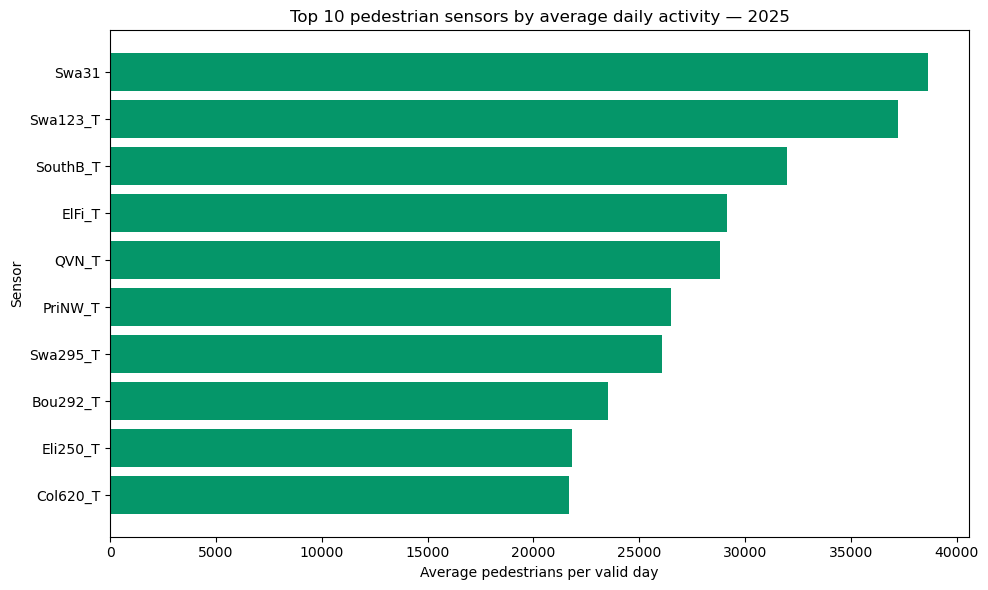

In [9]:
top_sensors = (
    usable_sensors
    .sort_values("average_daily_pedestrians", ascending=False)
    .head(10)
    .sort_values("average_daily_pedestrians")
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_sensors["sensor_name"],
    top_sensors["average_daily_pedestrians"],
    color="#059669"
)
plt.xlabel("Average pedestrians per valid day")
plt.ylabel("Sensor")
plt.title(f"Top 10 pedestrian sensors by average daily activity — {ANALYSIS_YEAR}")
plt.tight_layout()
plt.show()


<div id="subsection-4-2" class="usecase-sub-section-heading"><b>4.2. Create the combined map</b></div>
<div class="usecase-body">The heatmap is weighted by the normalised average daily pedestrian measure, while fountain markers show the locations of existing drinking fountains.</div>

In [10]:
melbourne_map = folium.Map(
    location=[-37.8136, 144.9631],
    zoom_start=13,
    tiles="CartoDB positron"
)

# Heatmap of average daily pedestrian activity using the MOP template green palette.
heat_data = [
    [
        row["lat"],
        row["lon"],
        row["average_daily_pedestrians"]
    ]
    for _, row in usable_sensors.iterrows()
]

HeatMap(
    heat_data,
    radius=25,
    min_opacity=0.45,
    gradient={
        0.20: "#D1FAE5",
        0.40: "#6EE7B7",
        0.60: "#34D399",
        0.80: "#059669",
        1.00: "#065F46"
    }
).add_to(melbourne_map)

# Add existing fountain locations as small markers.
for _, row in fountain_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color="#059669",
        fill=True,
        fill_color="#059669",
        fill_opacity=0.8,
        tooltip=f"Drinking fountain: {row['description']}"
    ).add_to(melbourne_map)

# Legend explaining the pedestrian-activity shading.
legend_html = """
<div style="position: fixed; bottom: 35px; left: 35px; z-index: 9999;
     background: white; border: 2px solid #059669; border-radius: 6px;
     padding: 10px 12px; font-size: 12px; line-height: 1.5;
     box-shadow: 0 1px 5px rgba(0,0,0,0.25);">
<b style="color:#059669;">Pedestrian activity</b><br>
<span style="display:inline-block;width:18px;height:10px;background:#D1FAE5;margin-right:4px;"></span>Lower<br>
<span style="display:inline-block;width:18px;height:10px;background:#34D399;margin-right:4px;"></span>Medium<br>
<span style="display:inline-block;width:18px;height:10px;background:#059669;margin-right:4px;"></span>Higher<br>
<span style="display:inline-block;width:18px;height:10px;background:#065F46;margin-right:4px;"></span>Highest
</div>
"""
melbourne_map.get_root().html.add_child(folium.Element(legend_html))

MousePosition(
    position="topright",
    separator=" | ",
    prefix="Coordinates:"
).add_to(melbourne_map)

melbourne_map


<div id="section-5" class="usecase-section-heading"><b>5. Perform Spatial Coverage Analysis</b></div>
<div class="usecase-body">This section measures the distance from each pedestrian sensor to its nearest published drinking fountain.</div>

<div id="subsection-5-1" class="usecase-sub-section-heading"><b>5.1. Calculate the nearest fountain distance</b></div>
<div class="usecase-body">The Haversine formula estimates great-circle distance between two latitude/longitude points. This is a straight-line screening distance and should not be interpreted as walking distance.</div>

In [11]:
def haversine_distance_matrix(sensor_lat, sensor_lon, fountain_lat, fountain_lon):
    """
    Calculate great-circle distances in metres between every sensor
    and every drinking fountain.
    """
    earth_radius_m = 6_371_000

    sensor_lat = np.radians(np.asarray(sensor_lat))[:, None]
    sensor_lon = np.radians(np.asarray(sensor_lon))[:, None]
    fountain_lat = np.radians(np.asarray(fountain_lat))[None, :]
    fountain_lon = np.radians(np.asarray(fountain_lon))[None, :]

    delta_lat = fountain_lat - sensor_lat
    delta_lon = fountain_lon - sensor_lon

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(sensor_lat)
        * np.cos(fountain_lat)
        * np.sin(delta_lon / 2) ** 2
    )

    return (
        2
        * earth_radius_m
        * np.arcsin(np.sqrt(a))
    )


if fountain_df.empty:
    raise ValueError("No drinking fountain records with usable coordinates are available for the spatial analysis.")

distance_matrix = haversine_distance_matrix(
    usable_sensors["lat"].values,
    usable_sensors["lon"].values,
    fountain_df["lat"].values,
    fountain_df["lon"].values
)

nearest_fountain_index = np.argmin(distance_matrix, axis=1)

usable_sensors["nearest_fountain_distance_m"] = (
    distance_matrix[
        np.arange(distance_matrix.shape[0]),
        nearest_fountain_index
    ]
)

usable_sensors["nearest_fountain_description"] = (
    fountain_df.iloc[nearest_fountain_index]["description"].to_numpy()
)

display(
    usable_sensors[
        [
            "sensor_name",
            "average_daily_pedestrians",
            "nearest_fountain_distance_m",
            "nearest_fountain_description"
        ]
    ]
    .sort_values("nearest_fountain_distance_m", ascending=False)
    .head(15)
)


,sensor_name,average_daily_pedestrians,nearest_fountain_distance_m,nearest_fountain_description
86,Spen475_T,"1,106.62",312.93,Leaf Type - Dog Bowl - Eades Park
87,Spen484_T,"1,312.03",265.49,Leaf Type - Dog Bowl - Eades Park
85,Lat526_T,"2,839.35",257.12,Stainless Steel Drinking Fountain - Leaf Type
7,Col700_T,"12,586.67",257.06,Stainless Steel Drinking Fountain - Leaf Type
88,Lat526_T,"1,399.96",254.64,Stainless Steel Drinking Fountain - Leaf Type
32,UM3_T,"1,822.61",244.40,Stainless Steel Drinking Fountain - Leaf Type
75,Spen161_T,"11,395.45",219.37,Stainless Steel Drinking Fountain - Leaf Type ...
19,MCEC_T,"17,271.04",207.74,Leaf Type - Dog Bowl - Batman Park
74,Spen201_T,"12,234.26",199.48,Stainless Steel Drinking Fountain - Leaf Type
71,King2_T,"3,947.10",189.43,Leaf Type - With Bottle Refill Tap - Enterpriz...


<div id="subsection-5-2" class="usecase-sub-section-heading"><b>5.2. Test fountain coverage assumptions</b></div>
<div class="usecase-body">The 150 metre radius is the primary screening assumption. Two additional radii are tested to show how sensitive the coverage result is to the selected distance.</div>

In [12]:
coverage_results = []

for radius in [100, 150, 250]:
    covered = (
        usable_sensors["nearest_fountain_distance_m"] <= radius
    )

    coverage_results.append({
        "radius_m": radius,
        "sensors_covered": int(covered.sum()),
        "sensors_without_fountain": int((~covered).sum()),
        "coverage_percent": covered.mean() * 100
    })

coverage_summary = pd.DataFrame(coverage_results)

display(coverage_summary)

usable_sensors["fountain_coverage_gap"] = (
    usable_sensors["nearest_fountain_distance_m"]
    > FOUNTAIN_COVERAGE_RADIUS_M
)


,radius_m,sensors_covered,sensors_without_fountain,coverage_percent
0,100,51,30,62.96
1,150,65,16,80.25
2,250,76,5,93.83


<div id="section-6" class="usecase-section-heading"><b>6. Identify Potential Fountain Gaps</b></div>
<div class="usecase-body">This section combines pedestrian activity and fountain distance to produce a transparent list of locations that warrant further investigation.</div>

<div id="subsection-6-1" class="usecase-sub-section-heading"><b>6.1. Create the screening list</b></div>
<div class="usecase-body">A potential gap must satisfy both conditions: it is in the high-activity group and the nearest published fountain is more than 150 metres away.</div>

In [13]:
potential_locations = usable_sensors[
    usable_sensors["high_activity"]
    & usable_sensors["fountain_coverage_gap"]
].copy()

# Rank by average daily pedestrian activity, then by fountain distance.
potential_locations = potential_locations.sort_values(
    ["average_daily_pedestrians", "nearest_fountain_distance_m"],
    ascending=[False, False]
).reset_index(drop=True)

potential_locations["screening_rank"] = (
    potential_locations.index + 1
)

screening_columns = [
    "screening_rank",
    "sensor_name",
    "average_daily_pedestrians",
    "valid_day_coverage",
    "nearest_fountain_distance_m",
    "nearest_fountain_description"
]

screening_table = potential_locations[screening_columns].copy()

print(
    f"Potential fountain-gap locations identified: "
    f"{len(screening_table):,}"
)

display(screening_table)


Potential fountain-gap locations identified: 2


,screening_rank,sensor_name,average_daily_pedestrians,valid_day_coverage,nearest_fountain_distance_m,nearest_fountain_description
0,1,MCEC_T,"17,271.04",0.98,207.74,Leaf Type - Dog Bowl - Batman Park
1,2,Bou688_T,"16,439.90",1.00,168.99,Stainless Steel Drinking Fountain - Leaf Type ...


<div id="subsection-6-2" class="usecase-sub-section-heading"><b>6.2. Visualise potential locations</b></div>
<div class="usecase-body">The candidate map highlights the locations that satisfy the screening rules and displays the pedestrian activity and distance-to-fountain information in each marker.</div>

In [14]:
candidate_map = folium.Map(
    location=[-37.8136, 144.9631],
    zoom_start=13,
    tiles="CartoDB positron"
)

# Existing fountains.
for _, row in fountain_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        color="#059669",
        fill=True,
        fill_color="#059669",
        fill_opacity=0.75,
        tooltip=f"Existing fountain: {row['description']}"
    ).add_to(candidate_map)

# Potential gap locations.
# Folium's named icon palette does not provide the MOP template orange hex, so the closest named 'orange' is used.
for _, row in potential_locations.iterrows():
    popup_text = (
        f"<b>Rank:</b> {int(row['screening_rank'])}<br>"
        f"<b>Sensor:</b> {row['sensor_name']}<br>"
        f"<b>Average daily pedestrians:</b> "
        f"{row['average_daily_pedestrians']:,.0f}<br>"
        f"<b>Nearest fountain:</b> "
        f"{row['nearest_fountain_distance_m']:,.0f} m"
    )

    folium.Marker(
        location=[row["lat"], row["lon"]],
        tooltip=f"Potential fountain gap: {row['sensor_name']}",
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(
            icon="tint",
            prefix="fa",
            color="orange"
        )
    ).add_to(candidate_map)

MousePosition(
    position="topright",
    separator=" | ",
    prefix="Coordinates:"
).add_to(candidate_map)

candidate_map


<div id="section-7" class="usecase-section-heading"><b>7. Results</b></div>
<div class="usecase-body">This section summarises the screening results from the analysis and explains what the results show.</div>


<div id="subsection-7-1" class="usecase-sub-section-heading"><b>7.1. Interpret the results</b></div>
<div class="usecase-body">The following summary is generated from the data when the notebook is run, so it remains consistent with the current API response rather than relying on an outdated hard-coded result.</div>

In [15]:
high_activity_count = int(usable_sensors["high_activity"].sum())
gap_count = int(len(potential_locations))

print(
    f"Analysis year: {ANALYSIS_YEAR}\n"
    f"Sensors with sufficient data coverage: {len(usable_sensors):,}\n"
    f"High-activity sensors: {high_activity_count:,}\n"
    f"Potential fountain-gap locations: {gap_count:,}\n"
    f"Primary fountain screening radius: {FOUNTAIN_COVERAGE_RADIUS_M} m"
)

if gap_count > 0:
    print(
        "\nThe identified locations are screening candidates for further "
        "investigation, not automatic recommendations for construction."
    )
else:
    print(
        "\nNo locations met all screening conditions under the selected "
        "assumptions. This does not mean every pedestrian location has "
        "adequate real-world access to drinking water."
    )


Analysis year: 2025
Sensors with sufficient data coverage: 81
High-activity sensors: 21
Potential fountain-gap locations: 2
Primary fountain screening radius: 150 m

The identified locations are screening candidates for further investigation, not automatic recommendations for construction.


<div class="usecase-unnumbered-heading"><b>Conclusion</b></div>

<div class="usecase-body">

Returning to the scenario, the purpose of this analysis is to compare 2025 pedestrian activity with existing drinking-fountain locations and identify areas with high pedestrian activity and limited nearby fountain access. The screening results provide evidence for further investigation and planning decisions rather than determining where a fountain must be installed.

This use case demonstrates a reproducible method for combining pedestrian activity, fountain locations and spatial proximity analysis. The candidate list should be treated as a screening output rather than a final infrastructure recommendation.

</div>

<div class="usecase-body"><b>What we achieved</b></div>

<div class="usecase-list">

- Retrieved the two required City of Melbourne datasets through the API.
- Limited the pedestrian analysis to the complete 2025 calendar year.
- Checked missing values, duplicates, coordinate validity and pedestrian-count validity.
- Converted hourly observations into daily totals and removed days with insufficient hourly coverage.
- Normalised pedestrian activity to an average number of pedestrians per valid day.
- Used the 75th percentile to identify relatively high-activity sensors.
- Calculated the nearest drinking-fountain distance using the Haversine formula.
- Tested 100 m, 150 m and 250 m coverage assumptions.
- Produced a screening table and interactive maps for potential fountain gaps.

</div>

<div class="usecase-body"><b>What we learned</b></div>
<div class="usecase-body">The analysis shows why cumulative counts are unsuitable when sensors have different observation histories. A normalised measure provides a more comparable basis for identifying relatively high pedestrian activity. It also demonstrates that spatial proximity can be used to screen infrastructure gaps, while recognising that straight-line distance is only an approximation of real pedestrian access.</div>

<div class="usecase-body"><b>Limitations</b></div>
<div class="usecase-body">

- **Pedestrian counts represent movements through sensor zones.** They should not be interpreted as counts of unique people.
- **Sensor histories can differ.** The revised valid-day coverage rule reduces, but does not completely remove, comparability issues.
- **The 75th percentile is an exercise threshold.** It identifies relatively busy sensors in this dataset; it is not a City of Melbourne policy threshold.
- **The 150 metre distance is an assumption.** The sensitivity analysis at 100 m and 250 m shows how the result changes when the assumption changes.
- **Haversine distance is straight-line distance.** It does not account for roads, crossings, barriers, buildings or actual walking routes.
- **A published fountain location does not guarantee current operational condition, accessibility or water availability.**
- **A pedestrian sensor is not necessarily a proposed construction site.** Land ownership, utilities, footpath width, accessibility, maintenance requirements and planning constraints would need to be checked before any decision.
- **The 2025 period is a single year.** Seasonal patterns, major events, construction and unusual conditions can influence pedestrian activity.

</div>

<div class="usecase-body"><b>Observations for further opportunities</b></div>
<div class="usecase-body">Further work could include walking-network distance, multiple years of normalised pedestrian activity, weekday versus weekend analysis, seasonal analysis, event information, fountain operational status, accessibility information and a formal multi-criteria site-selection model. These additions could make the screening process more useful for infrastructure planning.</div>
